# Wykrywanie początku gitary za pomocą PyTorch - Potok wykrywania początku gitary
Opis:
Kompleksowy potok do wykrywania początku gitary przy użyciu LSTM z:
- Wstępne przetwarzanie dźwięku
- Uczenie wielozadaniowe (początek, aktywny, wysokość dźwięku)
- Generowanie MIDI
- Wizualizacja

## 1. Instalacja i konfiguracja

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install librosa==0.11.0
%pip install mirdata==0.3.9
%pip install matplotlib==3.9.4
%pip install numpy==1.26.3
%pip install scikit-learn==1.6.1
%pip install tqdm==4.67.1
%pip install pretty_midi>=0.2.10
%pip install madmom==0.18.0
%pip install pypianoroll==1.0.2

^C
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


^C
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


^C
Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.


^C
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement madmom==0.18.0 (from versions: 0.12, 0.12.1, 0.13, 0.13.1, 0.13.2, 0.14, 0.14.1, 0.15, 0.15.1, 0.16, 0.16.1)
ERROR: No matching distribution found for madmom==0.18.0


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Podstawowe biblioteki
import os
import numpy as np
from tqdm import tqdm

# Przetwarzanie dźwięku
import librosa  # Analiza audio
import mirdata  # Dataset GuitarSet
import pretty_midi  # Obsługa plików MIDI

# Uczenie maszynowe
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

# Wizualizacja
import matplotlib.pyplot as plt

# Konfiguracja GPU - automatyczne wykrywanie
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")
if device.type == 'cuda':
    print(f"Model karty GPU: {torch.cuda.get_device_name(0)}")

Używane urządzenie: cuda
Model karty GPU: NVIDIA GeForce RTX 3070


## 2. Ładowanie i przygotowanie danych
### 2.1 Parametry audio 

In [3]:
## Parametry przetwarzania audio
SAMPLE_RATE = 44100  # Częstotliwość próbkowania [Hz]
HOP_LENGTH = 256     # Długość skoku między ramkami [próbki]
N_MELS = 128         # Liczba pasm melowych
SEQ_LENGTH = 256     # Długość sekwencji dla LSTM [ramki]
DATA_DIR = "guitarset_data"  # Folder na dane

### 2.2. Pobranie i wczytanie guitarset

In [4]:
def initialize_guitarset(data_dir="guitarset_data"):
    """Initialize and download GuitarSet if needed"""
    guitarset = mirdata.initialize("guitarset", data_home=data_dir)
    
    # Check if data exists
    example_track = guitarset.track(guitarset.track_ids[0])
    if not os.path.exists(example_track.audio_mic_path):
        print("Downloading GuitarSet data...")
        guitarset.download()
    else:
        print("GuitarSet data already exists")
    
    return guitarset

guitarset = initialize_guitarset()

GuitarSet data already exists


### 2.3. Funkcje przetwarzania danych

In [6]:
def load_audio_data(track_id, guitarset):
    """Ładuje audio i adnotacje dla wybranego utworu.
    
    Zwraca:
        audio: sygnał audio
        onsets: czasy początku nut [sekundy]
        durations: czas trwania nut [sekundy]
        pitches: wysokości nut w skali MIDI (0-127)
    """
    try:
        track = guitarset.track(track_id)
        audio, _ = librosa.load(track.audio_mic_path, sr=SAMPLE_RATE)
        notes = track.notes_all
        onsets = notes.intervals[:, 0]  # Początki nut
        durations = notes.intervals[:, 1] - notes.intervals[:, 0]  # Czas trwania
        pitches = notes.pitches  # Wysokości
        return audio, onsets, durations, pitches
    except Exception as e:
        print(f"Błąd przy ładowaniu utworu {track_id}: {str(e)}")
        return None, None, None, None

def create_spectrogram(audio):
    """Tworzy znormalizowany spektrogram melowy."""
    spectrogram = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH)
    log_spec = librosa.power_to_db(spectrogram, ref=np.max)
    # Normalizacja do zakresu [0, 1]
    log_spec = (log_spec - np.min(log_spec, axis=1, keepdims=True)) / \
               (np.max(log_spec, axis=1, keepdims=True) - np.min(log_spec, axis=1, keepdims=True) + 1e-8)
    return log_spec

def prepare_sequences(spectrogram, onsets, pitches, durations):
    """Przygotowuje sekwencje danych wejściowych i etykiet.
    
    Zwraca krotkę (X, y_onset, y_active, y_pitch):
        X: sekwencje spektrogramu
        y_onset: etykiety onsetów (0/1)
        y_active: etykiety aktywnych nut (0/1)
        y_pitch: etykiety wysokości dźwięku (0-127)
    """
    # Konwersja czasów do indeksów ramek
    frames = librosa.time_to_frames(onsets, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
    end_frames = librosa.time_to_frames(onsets + durations, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
    
    # Inicjalizacja etykiet
    onset_labels = np.zeros(spectrogram.shape[1])  # Wektor onsetów
    active_labels = np.zeros(spectrogram.shape[1])  # Wektor aktywności
    pitch_labels = np.zeros(spectrogram.shape[1], dtype=np.int64)  # Wektor pitchów
    
    # Wypełnianie etykiet na podstawie adnotacji
    for onset, end, pitch in zip(frames, end_frames, pitches):
        if onset < spectrogram.shape[1]:
            onset_labels[onset] = 1  # Zaznacz onset
            active_labels[onset:min(end, spectrogram.shape[1])] = 1  # Zaznacz aktywność
            pitch_labels[onset:min(end, spectrogram.shape[1])] = int(round(pitch))  # Zaznacz pitch
    
    # Podział na sekwencje
    X, y_onset, y_active, y_pitch = [], [], [], []
    for i in range(0, spectrogram.shape[1] - SEQ_LENGTH, SEQ_LENGTH // 2):
        X.append(spectrogram[:, i:i + SEQ_LENGTH].T)
        y_onset.append(onset_labels[i:i + SEQ_LENGTH])
        y_active.append(active_labels[i:i + SEQ_LENGTH])
        y_pitch.append(pitch_labels[i:i + SEQ_LENGTH])
    
    return (
        np.array(X), 
        np.expand_dims(np.array(y_onset), -1),  # Dodaj wymiar dla zgodności z modelem
        np.expand_dims(np.array(y_active), -1),
        np.array(y_pitch)
    )

### 2.4. Przygotowanie datasetu

In [7]:
track_ids = guitarset.track_ids 

# Inicjalizacja list na dane
all_X, all_y_onset, all_y_active, all_y_pitch = [], [], [], []

for track_id in track_ids:
    print(f"Przetwarzanie {track_id}...", end=" ")
    audio, onsets, durations, pitches = load_audio_data(track_id, guitarset)
    
    if audio is not None:
        spec = create_spectrogram(audio)
        X, y_onset, y_active, y_pitch = prepare_sequences(spec, onsets, pitches, durations)
        
        all_X.append(X)
        all_y_onset.append(y_onset)
        all_y_active.append(y_active)
        all_y_pitch.append(y_pitch)
        print(f"Gotowe - {X.shape[0]} sekwencji")
    else:
        print("Pominięto (błąd ładowania)")

# Łączenie danych ze wszystkich utworów
X = np.concatenate(all_X)
y_onset = np.concatenate(all_y_onset)
y_active = np.concatenate(all_y_active)
y_pitch = np.concatenate(all_y_pitch)

print(f"\nPodsumowanie:")
print(f"- Pełny zestaw danych: {X.shape[0]} sekwencji")
print(f"- Wymiary jednej sekwencji: {X.shape[1:]}")

# Podział na zbiór treningowy i walidacyjny
X_train, X_val, y_onset_train, y_onset_val, y_active_train, y_active_val, y_pitch_train, y_pitch_val = train_test_split(
    X, y_onset, y_active, y_pitch, test_size=0.2, random_state=42)

# Przygotowanie DataLoaderów dla PyTorch
train_dataset = TensorDataset(
    torch.FloatTensor(X_train), 
    torch.FloatTensor(y_onset_train),
    torch.FloatTensor(y_active_train),
    torch.LongTensor(y_pitch_train)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val), 
    torch.FloatTensor(y_onset_val),
    torch.FloatTensor(y_active_val),
    torch.LongTensor(y_pitch_val)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print(f"- Zbiór treningowy: {len(train_dataset)} sekwencji")
print(f"- Zbiór walidacyjny: {len(val_dataset)} sekwencji")

Przetwarzanie 00_BN1-129-Eb_comp... Gotowe - 29 sekwencji
Przetwarzanie 00_BN1-129-Eb_solo... Gotowe - 29 sekwencji
Przetwarzanie 00_BN1-147-Gb_comp... Gotowe - 25 sekwencji
Przetwarzanie 00_BN1-147-Gb_solo... Gotowe - 25 sekwencji
Przetwarzanie 00_BN2-131-B_comp... Gotowe - 38 sekwencji
Przetwarzanie 00_BN2-131-B_solo... Gotowe - 38 sekwencji
Przetwarzanie 00_BN2-166-Ab_comp... Gotowe - 30 sekwencji
Przetwarzanie 00_BN2-166-Ab_solo... Gotowe - 30 sekwencji
Przetwarzanie 00_BN3-119-G_comp... Gotowe - 42 sekwencji
Przetwarzanie 00_BN3-119-G_solo... Gotowe - 42 sekwencji
Przetwarzanie 00_BN3-154-E_comp... Gotowe - 32 sekwencji
Przetwarzanie 00_BN3-154-E_solo... Gotowe - 32 sekwencji
Przetwarzanie 00_Funk1-114-Ab_comp... Gotowe - 32 sekwencji
Przetwarzanie 00_Funk1-114-Ab_solo... Gotowe - 32 sekwencji
Przetwarzanie 00_Funk1-97-C_comp... Gotowe - 38 sekwencji
Przetwarzanie 00_Funk1-97-C_solo... Gotowe - 38 sekwencji
Przetwarzanie 00_Funk2-108-Eb_comp... Gotowe - 46 sekwencji
Przetwarzanie 

## 3. Definicja modelu

In [8]:
class AudioToMIDIModel(nn.Module):
    """Model LSTM do detekcji onsetów, aktywności nut i wysokości dźwięku.
    
    Architektura:
    1. Warstwy konwolucyjne do ekstrakcji cech
    2. Dwukierunkowy LSTM do analizy sekwencji
    3. Trzy oddzielne 'głowice' dla każdego zadania
    """
    
    def __init__(self, input_size):
        """Inicjalizacja modelu.
        
        Args:
            input_size: liczba pasm melowych (N_MELS)
        """
        super().__init__()
        
        # Warstwy konwolucyjne - ekstrakcja lokalnych cech
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),  # Zapobiega nadmiernemu dopasowaniu
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Dwukierunkowy LSTM - analiza sekwencji w obu kierunkach
        self.lstm = nn.LSTM(
            input_size=128, 
            hidden_size=256,
            batch_first=True,
            bidirectional=True,  # Dwukierunkowy
            num_layers=2  # Dwie warstwy LSTM
        )
        
        # Głowica do detekcji onsetów
        self.onset_head = nn.Sequential(
            nn.Linear(512, 128),  # 512 bo LSTM jest dwukierunkowy (256*2)
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Wyjście w zakresie [0,1] - prawdopodobieństwo onsetu
        )
        
        # Głowica do detekcji aktywnych nut
        self.active_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Prawdopodobieństwo aktywności
        )
        
        # Głowica do predykcji wysokości dźwięku
        self.pitch_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),  # 128 możliwych wartości pitchu (0-127)
            # Brak funkcji aktywacji - użyjemy CrossEntropyLoss
        )
    
    def forward(self, x):
        """Przebieg forward przez model.
        
        Args:
            x: tensor wejściowy (batch, czas, cechy)
            
        Returns:
            onset_output: przewidywane onsety (batch, czas, 1)
            active_output: przewidywana aktywność (batch, czas, 1)
            pitch_output: przewidywane pitchy (batch, czas, 128)
        """
        # Konwolucje wymagają kształtu (batch, cechy, czas)
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        
        # LSTM wymaga kształtu (batch, czas, cechy)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        
        # Przewidywania z poszczególnych głowic
        onset_output = self.onset_head(x)
        active_output = self.active_head(x)
        pitch_output = self.pitch_head(x)
        
        return onset_output, active_output, pitch_output

## 4. Trening modelu

In [9]:
def train_model(model, train_loader, val_loader, device, n_epochs=150):
    """Funkcja do trenowania modelu.
    
    Args:
        model: model do trenowania
        train_loader: DataLoader dla danych treningowych
        val_loader: DataLoader dla danych walidacyjnych
        device: urządzenie (CPU/GPU)
        n_epochs: liczba epok treningowych
    """
    # Inicjalizacja modelu
    model = model.to(device)
    
    # Funkcje strat - różne dla każdego zadania
    onset_criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([10.0]).to(device))  # Większa waga dla rzadkich onsetów
    active_criterion = nn.BCEWithLogitsLoss()
    pitch_criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignoruj pitch=0 (brak nuty)
    
    # Optymalizator i scheduler
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, verbose=True)
    
    # Śledzenie najlepszego modelu
    best_loss = float('inf')
    patience = 5
    no_improve = 0
    
    # Pętla treningowa
    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        
        # Pętla po batchach treningowych
        for X_batch, y_onset, y_active, y_pitch in tqdm(train_loader, desc=f"Epoka {epoch+1}"):
            X_batch = X_batch.to(device)
            y_onset = y_onset.to(device)
            y_active = y_active.to(device)
            y_pitch = y_pitch.to(device)
            
            # Zerowanie gradientów
            optimizer.zero_grad()
            
            # Forward pass
            onset_pred, active_pred, pitch_pred = model(X_batch)
            
            # Obliczanie strat
            loss_onset = onset_criterion(onset_pred, y_onset)
            loss_active = active_criterion(active_pred, y_active)
            loss_pitch = pitch_criterion(
                pitch_pred.permute(0, 2, 1),  # CrossEntropy wymaga (N, C, T)
                y_pitch)
            
            # Łączna strata (ważona suma)
            total_loss = loss_onset + loss_active + loss_pitch
            
            # Backpropagacja
            total_loss.backward()
            optimizer.step()
            
            train_losses.append(total_loss.item())
        
        # Walidacja
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_onset, y_active, y_pitch in val_loader:
                X_batch = X_batch.to(device)
                y_onset = y_onset.to(device)
                y_active = y_active.to(device)
                y_pitch = y_pitch.to(device)
                
                onset_pred, active_pred, pitch_pred = model(X_batch)
                loss = onset_criterion(onset_pred, y_onset) + \
                       active_criterion(active_pred, y_active) + \
                       pitch_criterion(pitch_pred.permute(0, 2, 1), y_pitch)
                val_losses.append(loss.item())
        
        # Statystyki epoki
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        print(f"\nEpoka {epoch+1}:")
        print(f"- Strata treningowa: {avg_train_loss:.4f}")
        print(f"- Strata walidacyjna: {avg_val_loss:.4f}")
        
        # Aktualizacja scheduler'a
        scheduler.step(avg_val_loss)
        
        # Wczesne zatrzymanie
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print("Zapisano nowy najlepszy model!")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Wczesne zatrzymanie po {patience} epokach bez poprawy")
                break

# Inicjalizacja i trening modelu
print("Inicjalizacja modelu...")
model = AudioToMIDIModel(X_train.shape[2])  # X_train.shape[2] = N_MELS

print("\nRozpoczęcie treningu...")
train_model(model, train_loader, val_loader, device, n_epochs=100)

Inicjalizacja modelu...

Rozpoczęcie treningu...


C:\Users\lukig\Documents\Programming\music-transcription\python\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoka 1: 100%|██████████| 355/355 [00:16<00:00, 21.89it/s]



Epoka 1:
- Strata treningowa: 3.2734
- Strata walidacyjna: 2.7071
Zapisano nowy najlepszy model!


Epoka 2: 100%|██████████| 355/355 [00:16<00:00, 22.14it/s]



Epoka 2:
- Strata treningowa: 2.5619
- Strata walidacyjna: 2.4891
Zapisano nowy najlepszy model!


...


Epoka 51:
- Strata treningowa: 1.3472
- Strata walidacyjna: 1.7355


Epoka 52: 100%|██████████| 355/355 [00:15<00:00, 22.94it/s]



Epoka 52:
- Strata treningowa: 1.3463
- Strata walidacyjna: 1.7299


Epoka 53: 100%|██████████| 355/355 [00:15<00:00, 22.77it/s]



Epoka 53:
- Strata treningowa: 1.3460
- Strata walidacyjna: 1.7321
Wczesne zatrzymanie po 5 epokach bez poprawy


## 5. Ewaluacja modelu

In [10]:
def evaluate_model(model, val_loader, device):
    """Pełna ewaluacja modelu na zbiorze walidacyjnym.
    
    Zwraca:
        - prawdopodobieństwa i predykcje dla wszystkich trzech zadań
        - odpowiednie metryki jakościowe
    """
    model.eval()
    onset_probs, active_probs, pitch_preds = [], [], []
    true_onsets, true_active, true_pitches = [], [], []
    
    with torch.no_grad():
        for X_batch, y_onset, y_active, y_pitch in val_loader:
            X_batch = X_batch.to(device)
            
            # Forward pass
            onset_out, active_out, pitch_out = model(X_batch)
            
            # Zbieranie wyników
            onset_probs.append(onset_out.sigmoid().cpu().numpy())
            active_probs.append(active_out.sigmoid().cpu().numpy())
            pitch_preds.append(pitch_out.argmax(dim=2).cpu().numpy())
            
            # Zbieranie prawdziwych etykiet
            true_onsets.append(y_onset.cpu().numpy())
            true_active.append(y_active.cpu().numpy())
            true_pitches.append(y_pitch.cpu().numpy())
    
    # Konwersja do numpy i spłaszczenie
    onset_probs = np.concatenate(onset_probs).flatten()
    active_probs = np.concatenate(active_probs).flatten()
    pitch_preds = np.concatenate(pitch_preds).flatten()
    true_onsets = np.concatenate(true_onsets).flatten()
    true_active = np.concatenate(true_active).flatten()
    true_pitches = np.concatenate(true_pitches).flatten()
    
    return onset_probs, active_probs, pitch_preds, true_onsets, true_active, true_pitches

def calculate_metrics(onset_probs, active_probs, pitch_preds, 
                     true_onsets, true_active, true_pitches):
    """Oblicza kluczowe metryki jakościowe."""
    from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
    
    # Optymalne progi dla onsetów i aktywności
    onset_precision, onset_recall, onset_thresholds = precision_recall_curve(
        true_onsets, onset_probs)
    onset_f1 = 2 * (onset_precision * onset_recall) / (onset_precision + onset_recall + 1e-8)
    best_onset_thresh = onset_thresholds[np.argmax(onset_f1)]
    
    active_precision, active_recall, active_thresholds = precision_recall_curve(
        true_active, active_probs)
    active_f1 = 2 * (active_precision * active_recall) / (active_precision + active_recall + 1e-8)
    best_active_thresh = active_thresholds[np.argmax(active_f1)]
    
    # Dokładność pitchów tylko dla aktywnych nut
    active_mask = true_active.astype(bool)
    pitch_acc = accuracy_score(
        true_pitches[active_mask], 
        pitch_preds[active_mask])
    
    return {
        'onset_threshold': best_onset_thresh,
        'onset_f1': np.max(onset_f1),
        'active_threshold': best_active_thresh,
        'active_f1': np.max(active_f1),
        'pitch_accuracy': pitch_acc
    }

# Wykonanie ewaluacji
print("Rozpoczęcie ewaluacji modelu...")
onset_probs, active_probs, pitch_preds, true_onsets, true_active, true_pitches = evaluate_model(
    model, val_loader, device)

metrics = calculate_metrics(
    onset_probs, active_probs, pitch_preds,
    true_onsets, true_active, true_pitches)

print("\nWyniki ewaluacji:")
print(f"- Optymalny próg dla onsetów: {metrics['onset_threshold']:.4f}")
print(f"- F1 dla onsetów: {metrics['onset_f1']:.4f}")
print(f"- Optymalny próg dla aktywności: {metrics['active_threshold']:.4f}")
print(f"- F1 dla aktywności: {metrics['active_f1']:.4f}")
print(f"- Dokładność pitchów (tylko aktywne nuty): {metrics['pitch_accuracy']:.4f}")

Rozpoczęcie ewaluacji modelu...

Wyniki ewaluacji:
- Optymalny próg dla onsetów: 0.7292
- F1 dla onsetów: 0.5847
- Optymalny próg dla aktywności: 0.5191
- F1 dla aktywności: 0.9680
- Dokładność pitchów (tylko aktywne nuty): 0.8769


## 6. Wizualizacja

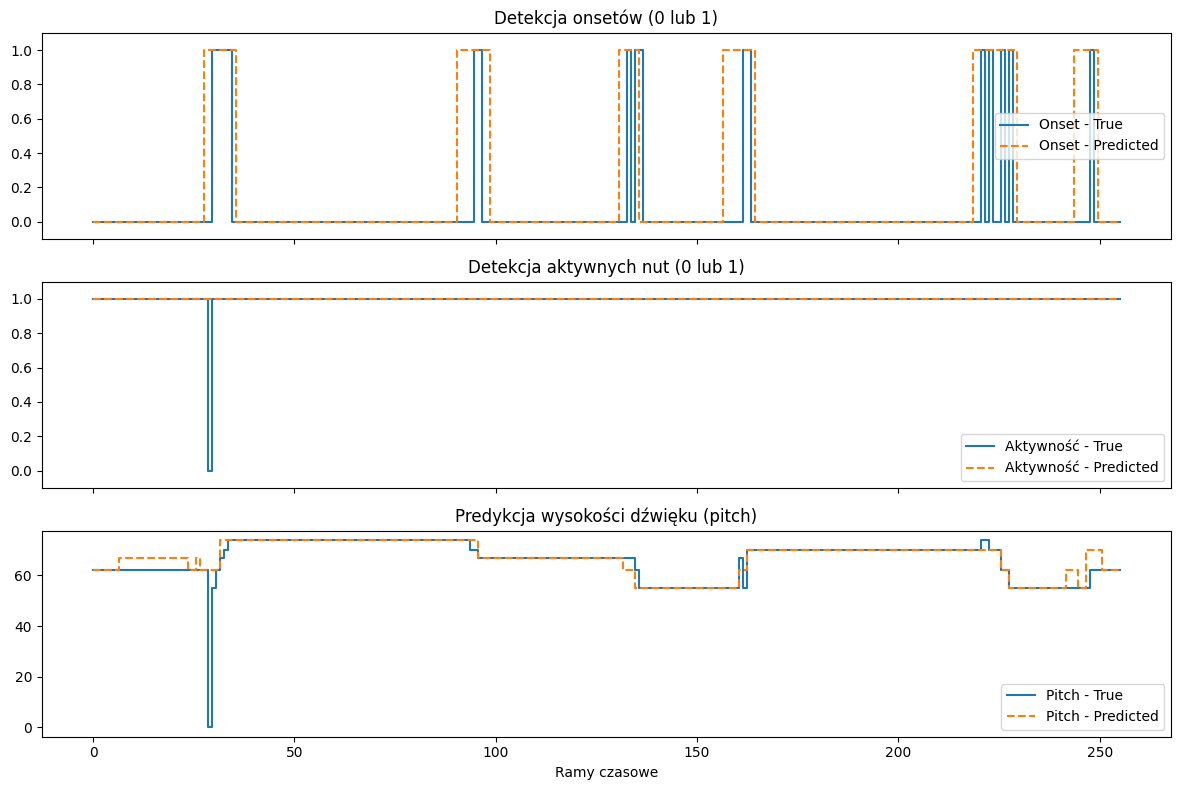

In [22]:
def plot_predictions_vs_truth(model, dataset, device, index=0, threshold=0.5):
    """Wizualizacja binarnych predykcji vs prawdy."""
    model.eval()

    X, y_onset, y_active, y_pitch = dataset[index]
    X_tensor = X.unsqueeze(0).to(device)

    with torch.no_grad():
        onset_pred, active_pred, pitch_pred = model(X_tensor)
        onset_pred = (onset_pred.squeeze(0).cpu().sigmoid().numpy() > threshold).astype(int)
        active_pred = (active_pred.squeeze(0).cpu().sigmoid().numpy() > threshold).astype(int)
        pitch_pred = pitch_pred.squeeze(0).cpu().argmax(dim=1).numpy()

    onset_true = y_onset.squeeze().numpy().astype(int)
    active_true = y_active.squeeze().numpy().astype(int)
    pitch_true = y_pitch.numpy()

    time = np.arange(len(onset_true))

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Onset
    axs[0].step(time, onset_true, label="Onset - True", where='mid')
    axs[0].step(time, onset_pred, label="Onset - Predicted", where='mid', linestyle="--")
    axs[0].set_ylim(-0.1, 1.1)
    axs[0].set_title("Detekcja onsetów (0 lub 1)")
    axs[0].legend()

    # Active
    axs[1].step(time, active_true, label="Aktywność - True", where='mid')
    axs[1].step(time, active_pred, label="Aktywność - Predicted", where='mid', linestyle="--")
    axs[1].set_ylim(-0.1, 1.1)
    axs[1].set_title("Detekcja aktywnych nut (0 lub 1)")
    axs[1].legend()

    # Pitch
    axs[2].step(time, pitch_true, label="Pitch - True", where='mid')
    axs[2].step(time, pitch_pred, label="Pitch - Predicted", where='mid', linestyle="--")
    axs[2].set_title("Predykcja wysokości dźwięku (pitch)")
    axs[2].legend()

    plt.xlabel("Ramy czasowe")
    plt.tight_layout()
    plt.show()

plot_predictions_vs_truth(model, val_dataset, device, index=0)